<a href="https://colab.research.google.com/github/shravani-n-10/gen_ai_hands_on/blob/main/FeedforwardNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
data=pd.read_csv('/content/predict_energy_consumption.xls')
data.head(3)

,temperature,humidity,wind_speed,solar_irradiance,energy_consumption
0,24.363503,31.107976,5.234114,705.432695,307.398145
1,38.767858,52.514057,4.939576,817.013257,412.444548
2,33.299849,72.376750,18.125092,325.421109,392.072418


In [ ]:
data.columns

Index(['temperature', 'humidity', 'wind_speed', 'solar_irradiance',
       'energy_consumption'],
      dtype='object')

In [ ]:
x=data[['temperature', 'humidity', 'wind_speed', 'solar_irradiance']]
y=data['energy_consumption']

In [ ]:
x_train,x_test,y_train,y_test= train_test_split(
    x,y,train_size=0.8,random_state=42
)

In [ ]:
x_train.shape

(800, 4)

In [ ]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
x_train

array([[-1.5340594 ,  1.07782942,  0.50747353,  0.50844492],
       [ 1.536054  , -1.3453489 ,  1.12953535, -1.24334131],
       [ 0.39406618, -1.52944037,  0.04035744, -1.59040298],
       ...,
       [ 0.95765999,  0.89800749,  1.24230548,  1.14414778],
       [ 0.70284634, -1.66035757, -0.40743025, -0.33869376],
       [-0.61845609,  1.26588496, -1.20769784,  1.49226399]])

In [ ]:
model=Sequential([
    Dense(64,activation='relu', input_shape=(x_train.shape[1],)),
    Dense(32,activation='relu')#heiddenlayer
    ,Dense(1)
])

In [ ]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [ ]:
history=model.fit(x_train,y_train,epochs=50
                  ,batch_size=32,validation_split=0.2,verbose=1)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 95813.4531 - mae: 280.3327 - val_loss: 83487.0234 - val_mae: 258.6325
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 93954.3281 - mae: 278.6938 - val_loss: 82819.3750 - val_mae: 257.3501
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 85557.3438 - mae: 262.6653 - val_loss: 81777.0469 - val_mae: 255.3347
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 87217.2188 - mae: 264.7996 - val_loss: 80188.9219 - val_mae: 252.2278
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 85680.1875 - mae: 262.4883 - val_loss: 77870.7812 - val_mae: 247.6132
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 86171.4688 - mae: 264.4382 - val_loss: 74590.1016 - val_mae: 240.9190
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 79149.4141 - mae: 250.3385 - val_loss: 70255.6875 - val_mae: 231.7613
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 69999.8984 - mae: 232.5025 - val_loss: 64823.

In [ ]:
test_loss,test_me=model.evaluate(x_test,y_test ,verbose=2)
print(f"test mean absolute error:{test_me:.2f}")

7/7 - 0s - 6ms/step - loss: 18065.4883 - mae: 115.6803
test mean absolute error:115.68


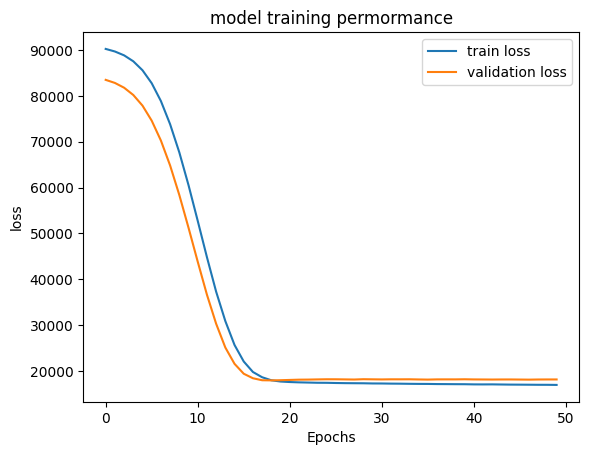

In [ ]:
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.title('model training permormance')
plt.legend()
plt.show()

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("techsash/waste-classification-data")

print("Path to dataset files:", path)

KaggleApiHTTPError: 403 Client Error.

You don't have permission to access resource at URL: https://www.kaggle.com/datasets/pramodgiri01/energy-consumption. The server reported the following issues: Permission 'datasets.get' was denied
Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.